# ftir_33 — how the two shape-based cohorts were selected, and why they fail

## tl;dr

The two shape-based cohorts get the same explainer treatment as filtering_by_ocec, from
committed selection tables only. Ethiopia-shaped smoke = the 300 smoke-pool filters
nearest the Addis medians in (CH, carbonyl/CH, 1600/CH) band-feature space (287 inside
the Addis 5–95% box, rounded to 300). Spectral analogs = the top 500 of the 13,010-filter
TOR-eligible pool ranked by mean percentile of nearest-Addis score-space D² and
VIP-weighted spectral RMSE (the locked 500 contains ftir_09's superseded 400). On the
compositional ruler both selections sit at the pool's OC/EC median — overlap with the
lowest-OC/EC 800 is 1/300 and 17/500 — and both fail the locked site-held-out TOR test
(Ethiopia-shaped R² 0.00, slope −2.20; analogs flagged no-skill), reproduced here with
the fixed-cohort crossplots asserting the matrix numbers (1.59x − 3.67, 2.48x − 6.35).

## Context & Methods

`filtering_by_ocec.png` explains the lowest-OC/EC cohort in one picture: the pool's
OC/EC distribution, the cut at 2.27, Addis off to the left. The other two engineered
cohorts in the setup matrix — **Ethiopia-shaped smoke (300)** and **spectral analogs
(locked 500)** — have never had the same treatment. This notebook gives each one its
explainer: the selection axis, where the cut falls, what got selected — and then puts
all three cohorts on one compositional ruler, which is where the story resolves:
shape-based selection does not find Addis-like composition, and the locked TOR test
says so.

Committed inputs only:

- `smoke_cohort_spectral_selection.csv` — all 906 smoke-pool filters with the three
  Addis band features (CH, carbonyl, 1600-shoulder peak heights and their CH-ratios),
  the band-feature distance to Addis, the inside-Addis-5–95% flag, and the selected
  flag (phase-2 lineage).
- `selected_improve_addis_analogs.csv` + `analog_selection_audit.csv` — the ftir_09
  analog selection (400) with its full metric set (nearest-Addis D², Q residual,
  VIP-weighted spectral RMSE, rank score); `locked_analog_train_test_split.csv` — the
  **locked** cohort (500, a superset containing all 400) with rank scores and the
  site-disjoint train/TOR-test split. Lineage note: the matrix's old "400" label was
  this superseded selection; the locked cohort is 500.
- `improve_implied_mac_bridge.csv` (per-filter OC/EC for the whole matched pool),
  `lowest_ocec_800_cohort.csv`, and the ftir_21 predictions/summary tables for the
  fixed-cohort crossplots and the held-out TOR verdicts.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, "scripts")

OUT = Path("output/plots/ftir32")
OUT.mkdir(parents=True, exist_ok=True)
P2 = Path("..") / "ftir_hips_chem" / "output" / "tables"

GREY, BLUE, PURPLE, ACCENT, GOLD = "#8F8C84", "#2C6E9E", "#7A4FA3", "#B23327", "#B0792B"
INK = "#1A1D21"

def show(path, title):
    print(f"[figure] {title}: {path}")
    display(Image(filename=str(path)))

### 1. Ethiopia-shaped smoke (300) — nearest Addis in band-feature space

The selection ran **inside the smoke-906 pool**: for each smoke filter, measure the
three band features Addis is defined by (CH peak, carbonyl peak, 1600-shoulder peak,
taken as ratios to CH), compute a distance to the Addis medians in that 3-feature
space, and keep the closest. The cohort is the **top 300 by that distance** (the
working threshold landed near 287 and was rounded up — the 12 Aug meeting
recollection). The committed inside-the-box flag shows how thin true resemblance is:
only **4 of 906** smoke filters fall inside the Addis 5–95% range on all three
features simultaneously — "nearest Addis" is a relative ranking; almost nothing in
the smoke pool is actually Addis-like.

smoke pool 906 | inside Addis 5–95% on all three features: 4 | selected: 300 | distance cut: 7.116
[figure] Ethiopia-shaped selection explainer: output/plots/ftir32/eth_shaped_selection_explainer.png


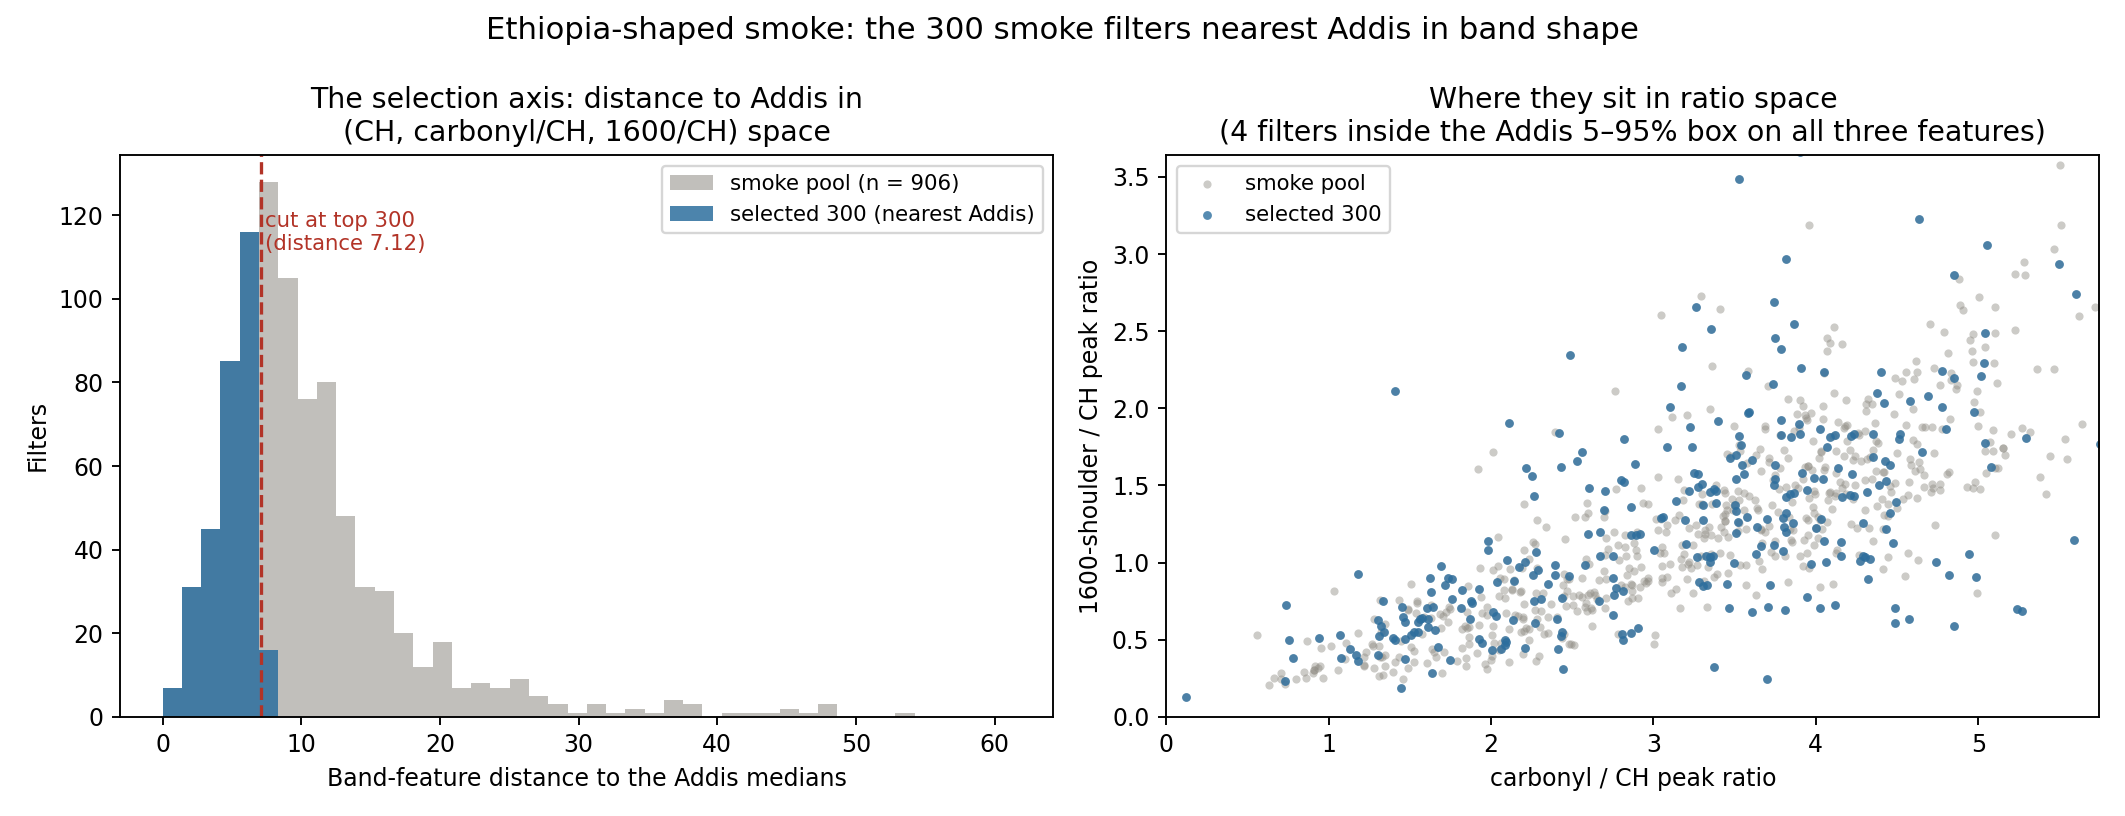

In [2]:
smoke = pd.read_csv(P2 / "pls_calibration_phase2" / "smoke_cohort_spectral_selection.csv")
assert len(smoke) == 906
sel = smoke[smoke.selected_Ethiopia_shaped_smoke]
inside = smoke[smoke.inside_Addis_5_95_range_all_three_features]
cut = sel.Addis_band_feature_distance.max()
print(f"smoke pool {len(smoke)} | inside Addis 5–95% on all three features: {len(inside)}"
      f" | selected: {len(sel)} | distance cut: {cut:.3f}")
assert len(sel) == 300 and len(inside) == 4

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
ax = axes[0]
bins = np.linspace(0, smoke.Addis_band_feature_distance.quantile(0.99), 45)
ax.hist(smoke.Addis_band_feature_distance, bins=bins, color=GREY, alpha=0.55,
        label=f"smoke pool (n = {len(smoke)})")
ax.hist(sel.Addis_band_feature_distance, bins=bins, color=BLUE, alpha=0.85,
        label=f"selected 300 (nearest Addis)")
ax.axvline(cut, color=ACCENT, ls="--", lw=1.4)
ax.text(cut * 1.04, ax.get_ylim()[1] * 0.9, f"cut at top 300\n(distance {cut:.2f})",
        color=ACCENT, fontsize=9, va="top")
ax.set_xlabel("Band-feature distance to the Addis medians")
ax.set_ylabel("Filters")
ax.set_title("The selection axis: distance to Addis in\n(CH, carbonyl/CH, 1600/CH) space")
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(smoke.carbonyl_to_CH, smoke.shoulder_1600_to_CH, s=12, color=GREY,
           alpha=0.45, lw=0, label="smoke pool")
ax.scatter(sel.carbonyl_to_CH, sel.shoulder_1600_to_CH, s=14, color=BLUE,
           alpha=0.8, lw=0, label="selected 300")
ax.set_xlabel("carbonyl / CH peak ratio")
ax.set_ylabel("1600-shoulder / CH peak ratio")
ax.set_xlim(0, smoke.carbonyl_to_CH.quantile(0.99))
ax.set_ylim(0, smoke.shoulder_1600_to_CH.quantile(0.99))
ax.set_title(f"Where they sit in ratio space\n({len(inside)} filters inside the Addis "
             "5–95% box on all three features)")
ax.legend(fontsize=9)
fig.suptitle("Ethiopia-shaped smoke: the 300 smoke filters nearest Addis in band shape",
             fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "eth_shaped_selection_explainer.png", dpi=170)
plt.close(fig)
show(OUT / "eth_shaped_selection_explainer.png", "Ethiopia-shaped selection explainer")

### 2. Spectral analogs (locked 500) — rank by score-space closeness

The selection ran over the **whole TOR-eligible pool** (13,010 filters), through a
fitted PLS score space: each filter gets a Mahalanobis D² to its nearest Addis
spectrum, a Q residual (how much of the spectrum the score space cannot represent),
and a VIP-weighted spectral RMSE against Addis (mismatch weighted toward the
wavenumbers the model actually uses). The rule — from the committed audit — ranks by
the **mean percentile of nearest-Addis D² and VIP-weighted RMSE**, and the locked
cohort keeps the top 500 (the earlier ftir_09 exploration kept 400; the locked 500
contains all of them). One structural caveat, from `K_SENSITIVITY_AUDIT.md`: this
selection runs *through a fitted model*, so unlike the OC/EC cut, the cohort's
membership itself depends on the component choice.

committed selection rule: mean percentile rank of nearest-Addis D2 and VIP-weighted RMSE | pool 13,010 → selected 400
locked cohort: 500 (train 372 / TOR test 128), spanning 127 sites


[figure] analog selection explainer: output/plots/ftir32/analog_selection_explainer.png


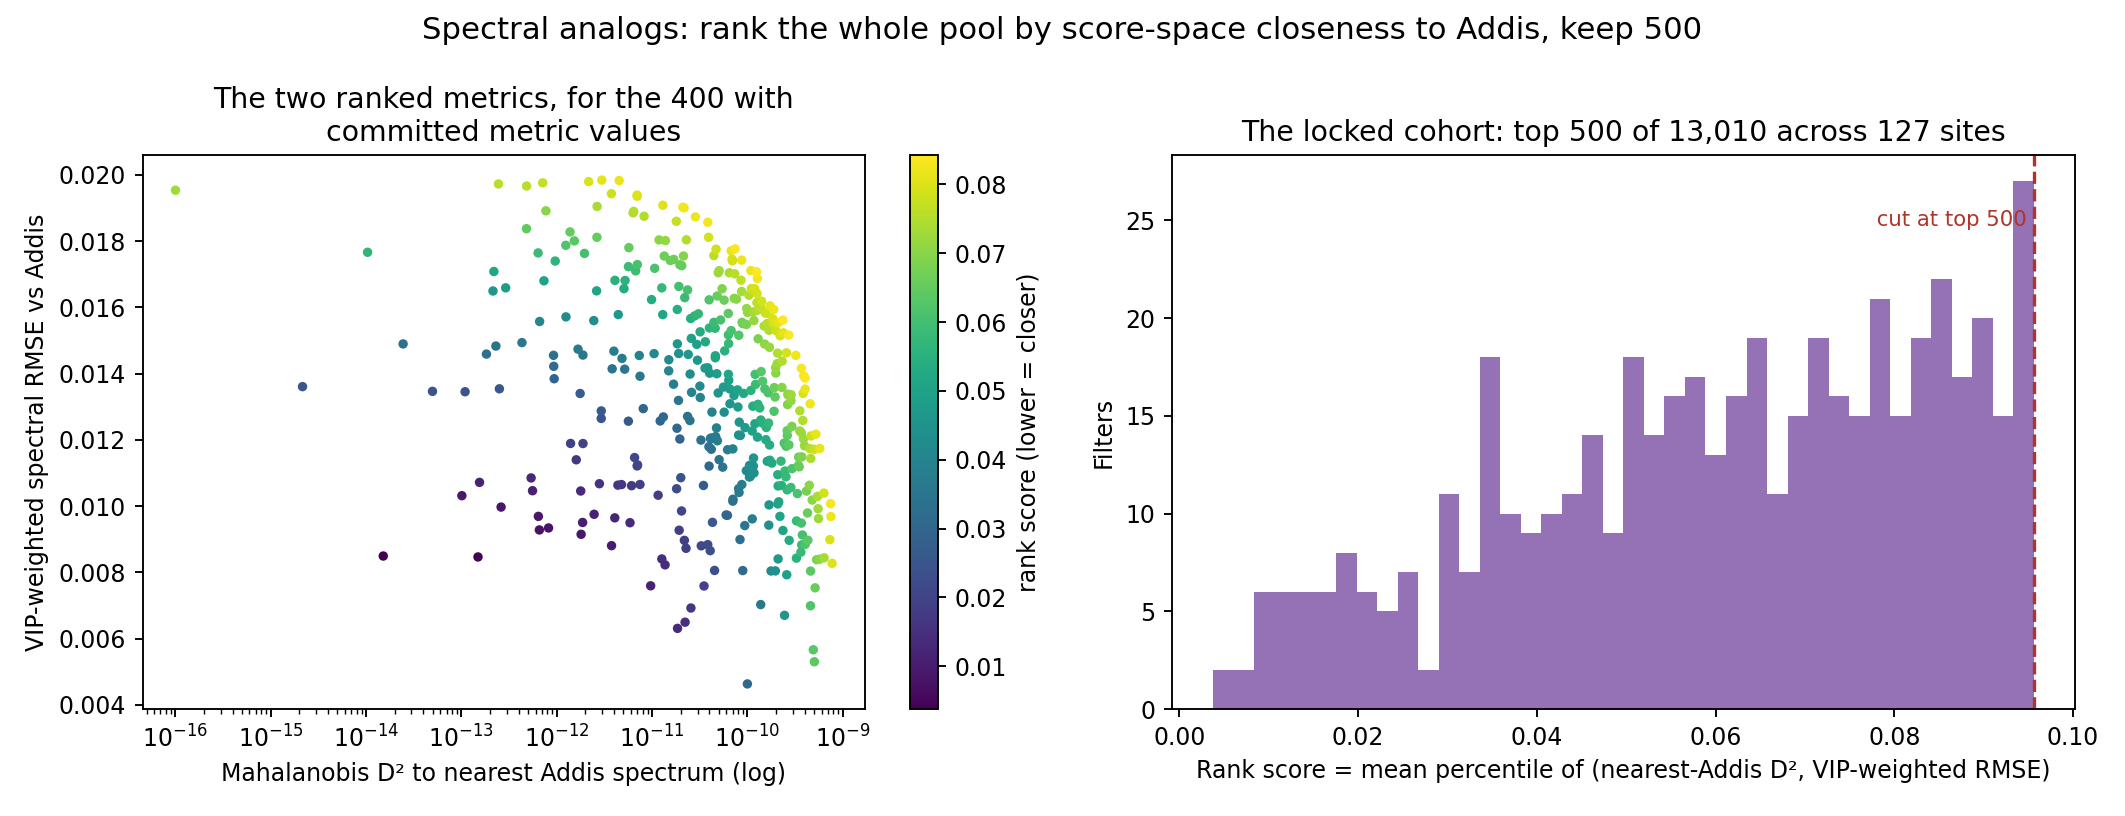

In [3]:
audit = pd.read_csv(P2 / "pls_transfer" / "analog_selection_audit.csv")
print("committed selection rule:", audit.selection_rule.iloc[0],
      f"| pool {audit.TOR_eligible_unique_filters.iloc[0]:,} → selected {audit.selected_analogs.iloc[0]}")
a400 = pd.read_csv(P2 / "pls_transfer" / "selected_improve_addis_analogs.csv")
locked = pd.read_csv(P2 / "pls_calibration_phase2" / "locked_analog_train_test_split.csv")
assert len(locked) == 500 and len(a400) == 400
assert set(a400.AnalysisId) <= set(locked.AnalysisId)
print(f"locked cohort: {len(locked)} (train {sum(locked.split == 'train')} / "
      f"TOR test {sum(locked.split != 'train')}), spanning {locked.Site.nunique()} sites")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
ax = axes[0]
sc = ax.scatter(a400.D2_to_nearest_Addis.clip(lower=1e-16), a400.VIP_weighted_spectral_RMSE,
                s=16, c=a400.analog_rank_score, cmap="viridis", lw=0)
ax.set_xscale("log")
ax.set_xlabel("Mahalanobis D² to nearest Addis spectrum (log)")
ax.set_ylabel("VIP-weighted spectral RMSE vs Addis")
ax.set_title("The two ranked metrics, for the 400 with\ncommitted metric values")
fig.colorbar(sc, ax=ax, label="rank score (lower = closer)")

ax = axes[1]
ax.hist(locked.analog_rank_score, bins=40, color=PURPLE, alpha=0.8)
ax.axvline(locked.analog_rank_score.max(), color=ACCENT, ls="--", lw=1.4)
ax.text(locked.analog_rank_score.max(), ax.get_ylim()[1] * 0.9, " cut at top 500 ",
        color=ACCENT, fontsize=9, ha="right", va="top")
ax.set_xlabel("Rank score = mean percentile of (nearest-Addis D², VIP-weighted RMSE)")
ax.set_ylabel("Filters")
ax.set_title(f"The locked cohort: top 500 of {audit.TOR_eligible_unique_filters.iloc[0]:,} "
             f"across {locked.Site.nunique()} sites")
fig.suptitle("Spectral analogs: rank the whole pool by score-space closeness to Addis, keep 500",
             fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "analog_selection_explainer.png", dpi=170)
plt.close(fig)
show(OUT / "analog_selection_explainer.png", "analog selection explainer")

### 3. All three cohorts on one compositional ruler

The lowest-OC/EC explainer's axis — TOR OC/EC — is the one that turned out to
transfer. Placing all three engineered cohorts on it shows why the two shape-based
selections behave so differently from the compositional one: **neither of them finds
low OC/EC.** The membership overlaps say the same thing — Ethiopia-shaped shares
**1 of 300** filters with the lowest-OC/EC 800, the locked analogs **17 of 500**.

overlap with lowest-OC/EC 800: Ethiopia-shaped 1/300 · analogs 17/500
Ethiopia-shaped smoke (300): 294 matched, median OC/EC 7.54
Spectral analogs (locked 500): 476 matched, median OC/EC 6.09
Lowest-OC/EC (800): 705 matched, median OC/EC 1.88


[figure] three cohorts on the OC/EC ruler: output/plots/ftir32/three_cohorts_one_ruler.png


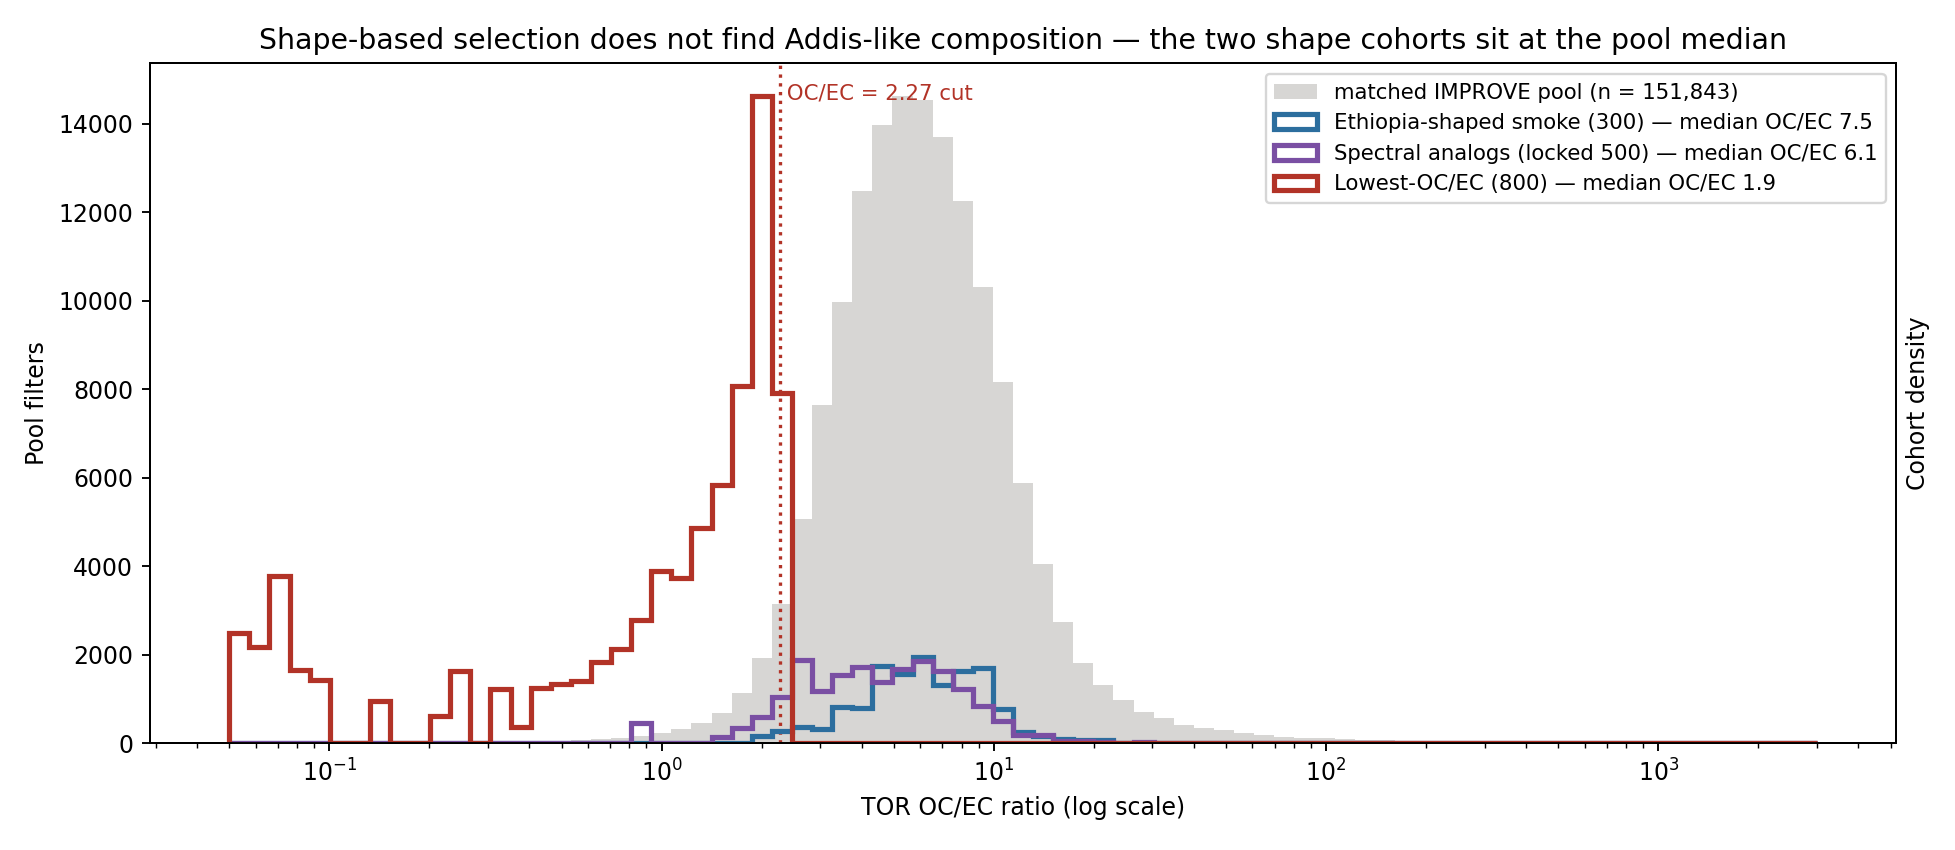

In [4]:
bridge = pd.read_csv("output/tables/ftir16/improve_implied_mac_bridge.csv")
ocec_of = (bridge[(bridge.EC_ugm3 > 0)]
           .drop_duplicates("FilterId").set_index("FilterId").OC_EC)
oc800 = pd.read_csv("output/tables/ftir11/lowest_ocec_800_cohort.csv")

cohorts = {
    "Ethiopia-shaped smoke (300)": (set(sel.FilterId), BLUE),
    "Spectral analogs (locked 500)": (set(locked.FilterId), PURPLE),
    "Lowest-OC/EC (800)": (set(oc800.FilterId), ACCENT),
}
ov_eth = len(set(sel.AnalysisId) & set(oc800.AnalysisId))
ov_ana = len(set(locked.AnalysisId) & set(oc800.AnalysisId))
assert (ov_eth, ov_ana) == (1, 17), (ov_eth, ov_ana)
print(f"overlap with lowest-OC/EC 800: Ethiopia-shaped {ov_eth}/300 · analogs {ov_ana}/500")

fig, ax = plt.subplots(figsize=(11.5, 5.0))
bins = np.geomspace(0.05, 3000, 80)
ax.hist(ocec_of.values, bins=bins, color=GREY, alpha=0.35,
        label=f"matched IMPROVE pool (n = {len(ocec_of):,})")
ax2 = ax.twinx()
for name, (ids, color) in cohorts.items():
    vals = ocec_of.reindex(list(ids)).dropna()
    med = vals.median()
    ax2.hist(vals, bins=bins, histtype="step", lw=2.2, color=color,
             label=f"{name} — median OC/EC {med:.1f}", density=True)
    print(f"{name}: {len(vals)} matched, median OC/EC {med:.2f}")
ax.axvline(2.27, color=ACCENT, ls=":", lw=1.4)
ax.text(2.27, ax.get_ylim()[1] * 0.97, " OC/EC = 2.27 cut ", color=ACCENT,
        fontsize=9, va="top")
ax.set_xscale("log")
ax.set_xlabel("TOR OC/EC ratio (log scale)")
ax.set_ylabel("Pool filters")
ax2.set_ylabel("Cohort density")
ax2.set_yticks([])
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, loc="upper right")
ax.set_title("Shape-based selection does not find Addis-like composition — "
             "the two shape cohorts sit at the pool median")
fig.tight_layout()
fig.savefig(OUT / "three_cohorts_one_ruler.png", dpi=170)
plt.close(fig)
show(OUT / "three_cohorts_one_ruler.png", "three cohorts on the OC/EC ruler")

### 4. What the locked test said — the outcome both explainers point at

Both shape-based cohorts produce Addis crossplots and pass nothing: under the
site-held-out protocol, Ethiopia-shaped smoke has **no held-out TOR skill**
(R² 0.00, slope −2.20) and the analogs carry the ⚠ for the same reason — while the
compositional cohort passes (R² 0.911). The crossplots below are the fixed-cohort
fits in **both component-protocol variants** (the app protocol has no TOR test by
construction — its k values are 17 and 9 against the site-held-out 10 and 4), each
asserted against the committed ftir_21 metrics table.

Ethiopia-shaped smoke (300)        held-out TOR R² = 0.004


Spectral analogs (locked 500)      held-out TOR R² = 0.367
Lowest-OC/EC (800)                 held-out TOR R² = 0.911
Lowest-OC/EC + AIRSpec (800)       held-out TOR R² = 0.904
[figure] shape-cohort crossplots — site-held-out: output/plots/ftir32/shape_cohorts_crossplots_site_heldout.png


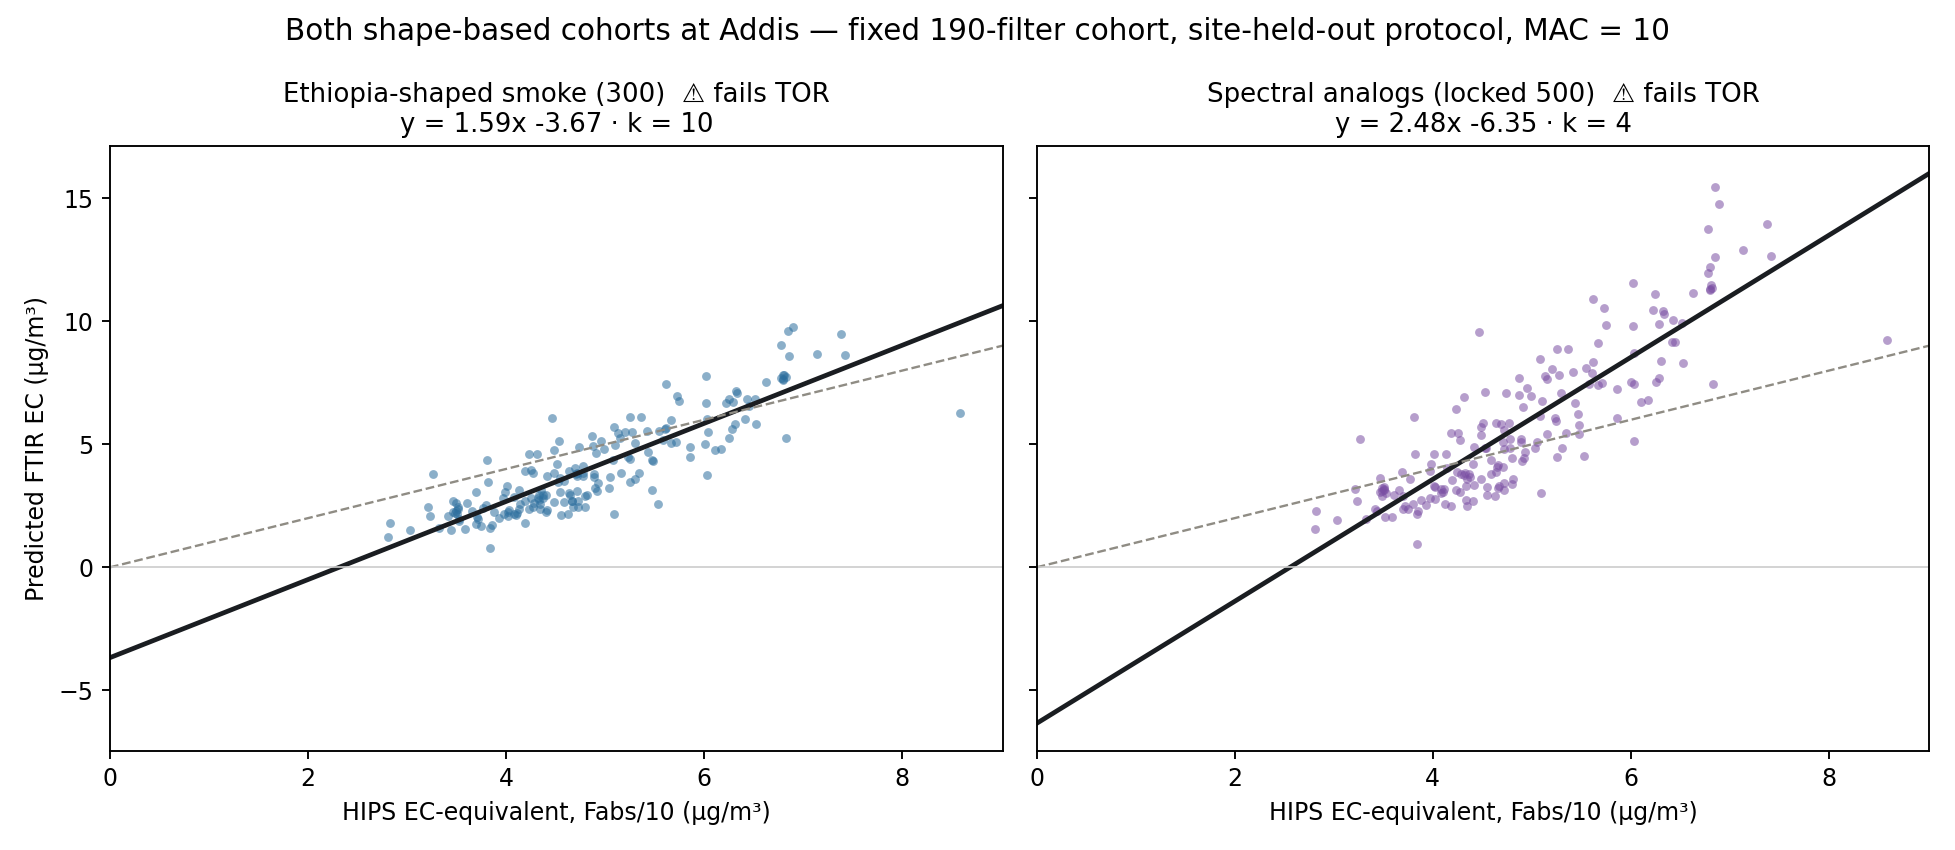

[figure] shape-cohort crossplots — calibration-app variant: output/plots/ftir32/shape_cohorts_crossplots_app.png


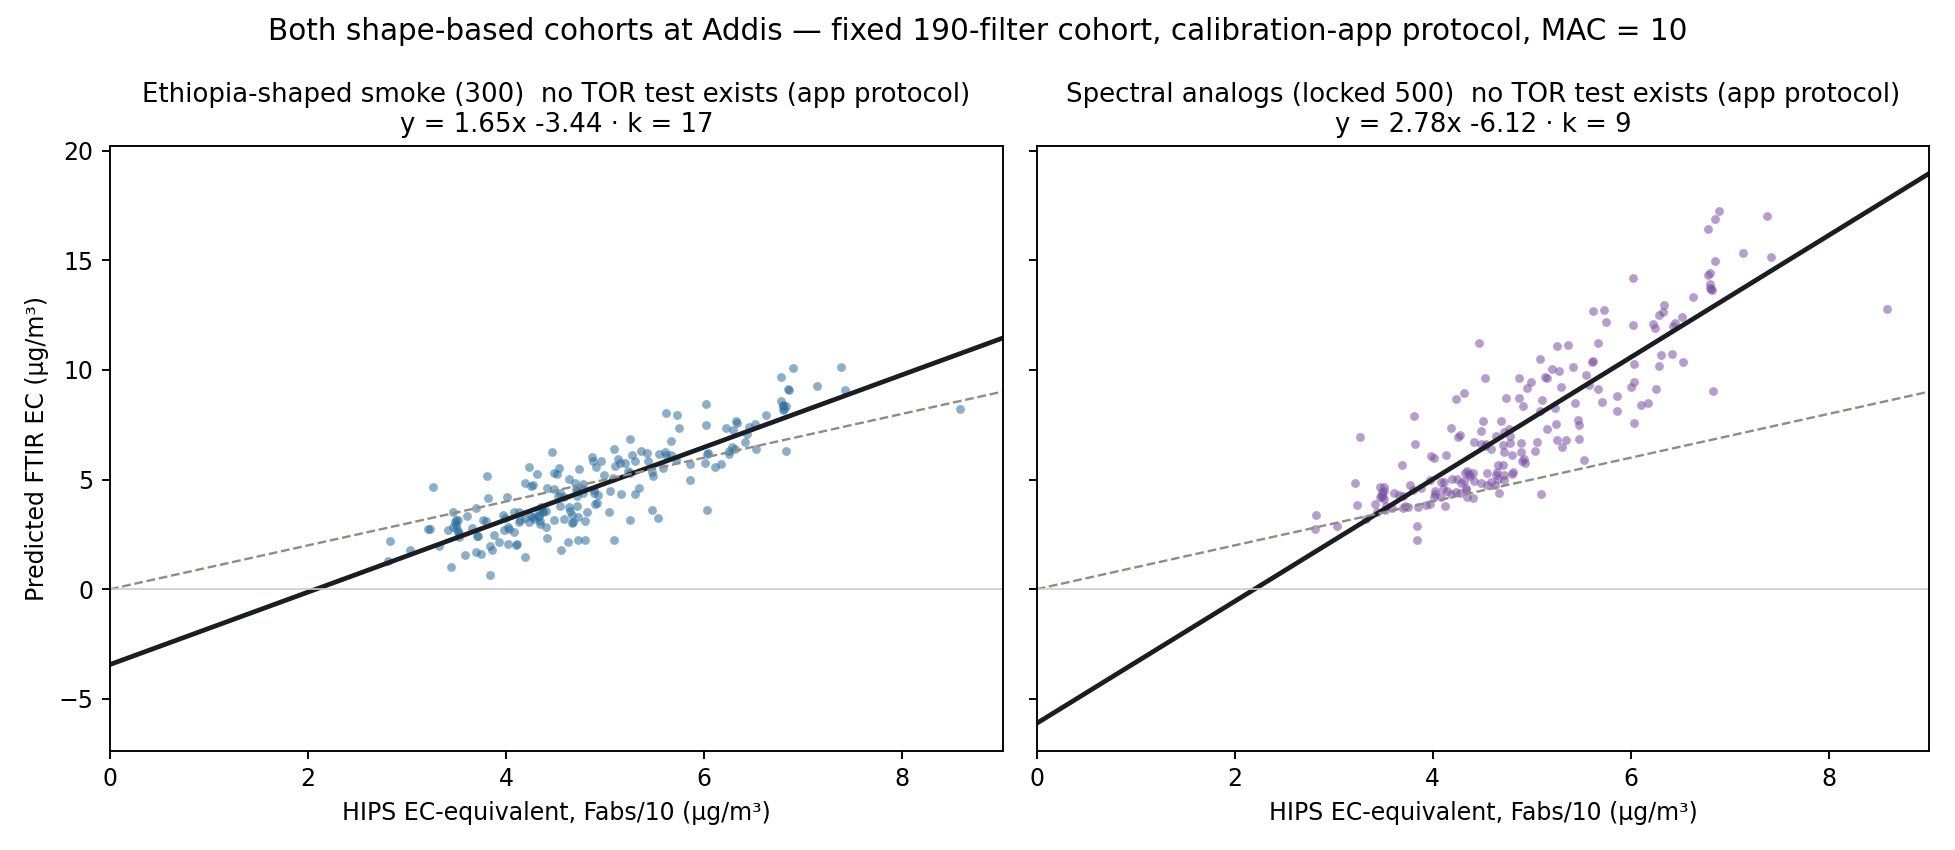

In [5]:
summary = pd.read_csv("output/tables/ftir21/calibration_summary_by_mode.csv")
shp = summary[summary["mode"] == "site_heldout"].set_index("cohort")
for name in ["Ethiopia-shaped smoke (300)", "Spectral analogs (locked 500)",
             "Lowest-OC/EC (800)", "Lowest-OC/EC + AIRSpec (800)"]:
    r2 = shp.loc[name, "heldout_TOR_R2"]
    verdict = f"{r2:.3f}" if pd.notna(r2) else "(not defined under this protocol)"
    print(f"{name:<34s} held-out TOR R² = {verdict}")
eth_r2 = shp.loc["Ethiopia-shaped smoke (300)", "heldout_TOR_R2"]
assert eth_r2 < 0.01, eth_r2

predictions = pd.read_csv("output/tables/ftir21/addis_predictions_by_mode.csv")
phase2 = pd.read_csv(P2 / "pls_calibration_phase2" / "addis_calibration_predictions.csv")
fixed = predictions[predictions.MediaId.isin(
    set(phase2.dropna(axis=0, how="any").MediaId))].reset_index(drop=True)
assert len(fixed) == 190

metrics = pd.read_csv("output/tables/ftir21/addis_metrics_by_mode.csv")
mfix = metrics[(metrics.MAC_m2_g == 10)
               & (metrics.evaluation_set == "fixed phase-2 cohort")].set_index(["cohort", "mode"])
x = fixed.Fabs.to_numpy(float) / 10.0
COHORTS = {"Ethiopia-shaped smoke (300)": BLUE,
           "Spectral analogs (locked 500)": PURPLE}

def fig_shape_crossplots(mode):
    tag = ("⚠ fails TOR" if mode == "site_heldout"
           else "no TOR test exists (app protocol)")
    label = "site-held-out" if mode == "site_heldout" else "calibration-app"
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0), sharex=True, sharey=True)
    for ax, (name, color) in zip(axes, COHORTS.items()):
        y = fixed[f"{name} [{mode}]"].to_numpy(float)
        s, b = np.polyfit(x, y, 1)
        row = mfix.loc[(name, mode)]
        # the refit must reproduce the committed metrics table for this mode
        assert (round(s, 2), round(b, 2)) == (round(row.slope, 2), round(row.intercept, 2)), \
            (name, mode, s, b, row.slope, row.intercept)
        hi = x.max() * 1.05
        ax.scatter(x, y, s=14, color=color, alpha=0.55, lw=0)
        ax.plot([0, hi], [b, b + s * hi], color=INK, lw=2)
        ax.plot([0, hi], [0, hi], "--", color=GREY, lw=1)
        ax.axhline(0, color="#CCCCCC", lw=0.7)
        ax.set_title(f"{name}  {tag}\ny = {s:.2f}x {b:+.2f} · k = {int(row.k)}", fontsize=11)
        ax.set_xlabel("HIPS EC-equivalent, Fabs/10 (µg/m³)")
        ax.set_xlim(0, hi)
    axes[0].set_ylabel("Predicted FTIR EC (µg/m³)")
    fig.suptitle(f"Both shape-based cohorts at Addis — fixed 190-filter cohort, "
                 f"{label} protocol, MAC = 10", fontsize=12.5)
    fig.tight_layout()
    path = OUT / f"shape_cohorts_crossplots_{mode}.png"
    fig.savefig(path, dpi=170)
    plt.close(fig)
    return path

show(fig_shape_crossplots("site_heldout"), "shape-cohort crossplots — site-held-out")
show(fig_shape_crossplots("app"), "shape-cohort crossplots — calibration-app variant")

## Takeaways

- Shape-similarity (band features or score space) does not select for composition:
  the axis that transfers to Addis is OC/EC, and neither shape cohort finds it.
- The analog cohort's membership runs through a fitted PLS model (k-dependent) —
  unlike the OC/EC cut, the selection itself is not protocol-free.
- Selection tables: smoke_cohort_spectral_selection.csv (906 rows, flags),
  selected_improve_addis_analogs.csv (400 + metrics), locked_analog_train_test_split.csv
  (the locked 500 with the site-disjoint split).